## **SUMMARY**
This script is used to attribute tax parcel and address point data downloaded from the City of Hayward into building footprints. Preprocessing of footprint data is conducted in a separate script. 

### **REQUIRED INPUTS**
Hayward Tax Parcel Data

Hayward Address Point Data

Hayward Footprint Data


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [1]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
import matplotlib.pyplot as plt
import folium
from collections import Counter
import matplotlib.patches as mpatches
import contextily as ctx
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from shapely.geometry import box
import matplotlib.lines as mlines


# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_local as inv_local 

In [2]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]


In [3]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_Local/'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **SECTION 1: Preprocess Address Data**

In [5]:
# Load address data downloaded from Hayward GIS
addresses = gpd.read_file('./Input_Data/Local/Hayward_Addresses.geojson')
addresses = addresses.to_crs(epsg=crs_main)

# Load Census blocks and tracts 
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')

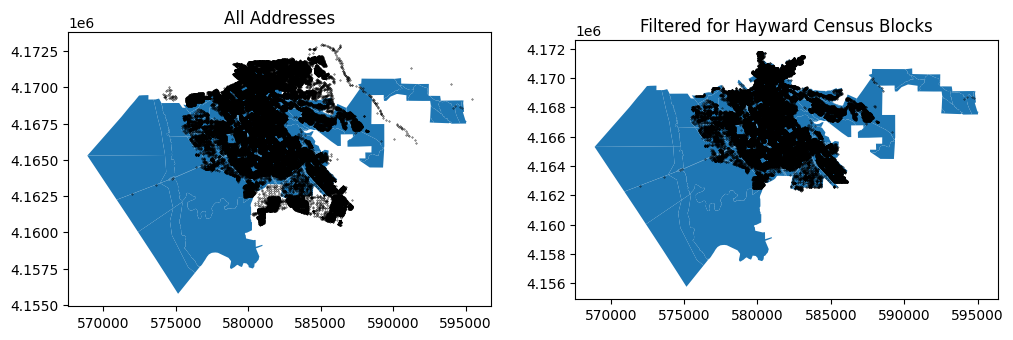

In [6]:
### FIND ADDRESSES THAT ARE WITHIN THE HAYWARD CENSUS BLOCKS ###

# Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
addresses.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Addresses')

# Assign block to addresses
addresses_copy = addresses.copy()
addresses_copy = addresses_copy.sjoin(hayward_blocks, how='left')
addresses.loc[:, 'CensusBlock'] = addresses_copy['GEOID10'].values

# Assign tract to addresses
addresses_copy = addresses.copy()
addresses_copy = addresses_copy.sjoin(hayward_tracts, how='left')
addresses.loc[:, 'CensusTract'] = addresses_copy['GEOID10'].values

# Drop rows that are not in blocks of interest (Hayward)
address_hayward = addresses[~addresses['CensusBlock'].isna()]

# Plot to check 
hayward_blocks.plot(ax=ax[1])
address_hayward.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Hayward Census Blocks')
plt.show()

In [7]:
### CLEAN ADDRESS DATA AND PREPARE FOR MERGE WITH SCRAPED DATA ###

# Remove exact duplicates from hayward res data 
print('All Hayward Address Points:',len(address_hayward))
address_hayward = address_hayward.drop_duplicates() # Remove exact duplicates
print('After exact duplicates:',len(address_hayward))

# Drop Unnecessary Columns -- not used in workflow 
address_hayward['Zone'].unique()
columns_to_drop = ['APN_GIS','Status','Affordability_Level','Affordable','Pre_Type','Zone','SitusAddress']
address_hayward = address_hayward.drop(columns=columns_to_drop)

# Add Columns to be filled by additional parcel data 
new_columns = ['ScrapeFlag','Scrape_Use_Description', 'Scrape_Use_Code', 'Scrape_Landslide','Scrape_Liquefaction','Scrape_Fault_Zone','Scrape_Total_Value','Scrape_Improvement_Value','Scrape_Homeowner_Exemption',
               'Scrape_Year_Built','Scrape_Eff_Year_Built','Scrape_Bldg_Class','Scrape_Construction','Scrape_Bldg_Condition','Scrape_Bldg_Quality','Scrape_Bldg_Area','Scrape_Num_Bldg',
               'Scrape_Num_Units','Scrape_Num_Stories','Scrape_Parking']
for column in new_columns:
    address_hayward[column] = None

# Set scrape flag of all data to be 0 - this will be modified as parcel data is associatd with address points 
address_hayward['ScrapeFlag'] = 0

# Save
inv_local.gdf_to_json(address_hayward, dir_intermediate + 'Address_for_Merge.json')


All Hayward Address Points: 63212
After exact duplicates: 63212
JSON File Saved


In [6]:
#### TEMPORARY 

# Load preprocessed footprint data 
footprints = inv_local.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)



In [9]:
multi = address_hayward[address_hayward['FeatureCode'].str.contains('Multi-Family')]
duplex = address_hayward[address_hayward['FeatureCode'].str.contains('Duplex')]

In [1]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in multi.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

In [2]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in duplex.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

## **SECTION 2: Preprocess Parcel Data**

In [6]:
# Load parcel data and Census blocks 
parcels = gpd.read_file('./Input_Data/Local/Hayward_Parcels.geojson')
parcels = parcels.to_crs(epsg=crs_main)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')

# Load extended parcel data from Hayward GIS 
scraped = pd.read_csv('./Input_Data/Local/Additional_Parcel_Information.csv', low_memory=False)

/var/folders/h5/xf79vsp167q_tf4t38sfv58c0000gn/T/ipykernel_67381/2876058278.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[    1     2     3 ... 68370 68371 68372]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  gdf_cleaned.update(dissolved)


0 duplicates


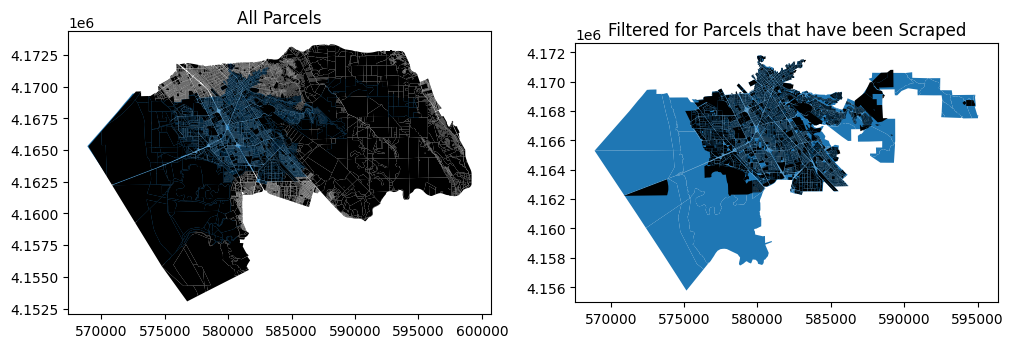

JSON File Saved


In [9]:
# Obtain parcels that have extended parcel data available 
scraped_apn = list(scraped['APN_PQ'].unique())
parcels_scrape = parcels[parcels['APN_PQ'].isin(scraped_apn)]

# Ensure unique APN_PQs by dissolving geometries for matching APN_PQ
duplicates = parcels_scrape[parcels_scrape.duplicated(subset=['APN_PQ'])]
dissolved = duplicates.dissolve(by='APN_PQ', as_index=False)
gdf_cleaned = parcels_scrape.drop_duplicates(subset='APN_PQ', keep='first')
gdf_cleaned = gdf_cleaned.set_index('APN_PQ')
dissolved = dissolved.set_index('APN_PQ')
gdf_cleaned.update(dissolved)
parcels_clean = gdf_cleaned.reset_index()

# Check for duplicate APN_PQ
duplicates = parcels_clean[parcels_clean.duplicated(subset='APN_PQ')]
print(len(duplicates),'duplicates')

#  Plot
fig, ax = plt.subplots(1,2, figsize = (12, 12))
hayward_blocks.plot(ax=ax[0])
parcels.plot(ax=ax[0], color ='black', markersize = 0.1)
ax[0].set_title('All Parcels')
hayward_blocks.plot(ax=ax[1])
parcels_clean.plot(ax=ax[1], color ='black', markersize = 0.1)
ax[1].set_title('Filtered for Parcels that have been Scraped')
plt.show()

# Save parcels that have scraped data available 
inv_local.gdf_to_json(parcels_clean.copy(), dir_intermediate + 'Scraped_Parcels.json')

## **SECTION 3: Tag Footprints with Possible Tax Parcels**

In [11]:
# Load parcel data 
parcels_clean = inv_local.json_to_gdf(dir_intermediate + 'Scraped_Parcels.json', crs_main)

# Load preprocessed footprint data 
footprints = inv_local.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)


In [11]:
### ASSIGN FOOTPRINTS TO PARCELS ###

# Perform spatial join to add APN_PQ from parcels_clean to footprints
footprints_with_apn = gpd.sjoin(footprints, parcels_clean[['APN_PQ', 'geometry']], how="left", predicate="intersects")
inv_local.gdf_to_json(footprints_with_apn, dir_intermediate + 'Footprints_with_Parcels_Unfiltered.json')

# Merge the parcel geometry to the footprints based on the spatial join
parcels_clean = parcels_clean.rename(columns={'geometry': 'parcel_geometry'})
footprints_with_apn = footprints_with_apn.merge(parcels_clean[['APN_PQ', 'parcel_geometry']], on='APN_PQ')

### DROP FOOTPRINT ASSOCIATION WITH SOME PARCELS BASED ON PERCENTAGE WITHIN EACH ###

# Calculate the area of each footprint
footprints_with_apn['footprint_area'] = footprints_with_apn.geometry.area

# Calculate the intersection area between the footprint and parcel geometries
footprints_with_apn['intersection'] = footprints_with_apn.geometry.intersection(footprints_with_apn['parcel_geometry'])
footprints_with_apn['intersection_area'] = footprints_with_apn['intersection'].area

# Calculate the percentage of the footprint that is within the parcel
footprints_with_apn['percent_overlap'] = (footprints_with_apn['intersection_area'] / footprints_with_apn['footprint_area']) * 100

# First, filter out rows where the overlap is less than a given % of the footprint wiht a given parcel 
# print(len(footprints_with_apn))
# footprints_with_apn_filter = footprints_with_apn[footprints_with_apn['percent_overlap'] >= 5]
# NOTE: in the case of Hayward, decided not to include this filter based on spot checking data 
footprints_with_apn_filter = footprints_with_apn

# Second, filter rows that have at least a given % of the footprint within a single parcel (drop other parcels associated with that house)
print(len(footprints_with_apn_filter))
ftpt_above = footprints_with_apn_filter[footprints_with_apn_filter['percent_overlap'] >= 95]
ftpt_ids_above = list(ftpt_above['FootprintID'].unique())
ftpt_below = footprints_with_apn_filter[footprints_with_apn_filter['percent_overlap'] < 95]
ftpt_below_reduced = ftpt_below[~ftpt_below['FootprintID'].isin(ftpt_ids_above)]

# Recombine dataframes 
footprints_filtered = pd.concat([ftpt_above, ftpt_below_reduced], axis=0, ignore_index=True)
print(len(footprints_filtered))

# Reset geometry and drop columns 
footprints_filtered = footprints_filtered.drop(columns=['intersection', 'footprint_area', 'intersection_area', 'percent_overlap', 'index_right','parcel_geometry'])
footprints_filtered.set_geometry('geometry', inplace=True)

# Remove duplicate rows 
print('With Duplicates:', len(footprints_filtered))
footprints_filtered = footprints_filtered.drop_duplicates(keep = 'first')
print('Without Duplicates:', len(footprints_filtered))

# Save data
inv_local.gdf_to_json(footprints_filtered, dir_intermediate + 'Footprints_with_Parcels_Filtered.json')


JSON File Saved
57353
50173
With Duplicates: 50173
Without Duplicates: 50173
JSON File Saved


## **SECTION 4: Attribute Address and Parcel Information to Footprints**

In [17]:
# Load parcel-level tax data and parcels 
scraped_merge = pd.read_csv('./Input_Data/Local/Additional_Parcel_Information.csv', low_memory=False)
parcels_clean = inv_local.json_to_gdf(dir_intermediate + 'Scraped_Parcels.json', crs_main)

# Load point-based address data
address_merge = inv_local.json_to_gdf(dir_intermediate + 'Address_for_Merge.json', crs_main)

# Load footprints (footprints_filtered contains parcel assignments, footprints_orig contains all footprint being used with no modification)
footprints_filtered = inv_local.json_to_gdf(dir_intermediate + 'Footprints_with_Parcels_Filtered.json', crs_main)
footprints_orig = inv_local.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# For the purposes of the data merge, only use address points with APN_PQs that have been scraped 
# There are 8 residential APN_PQs that were not scraped because they did not have property reports available 
address_merge = address_merge[address_merge['APN_PQ'].isin(list(scraped_merge['APN_PQ'].unique()))]

# Create new columns to be used in merge 
address_merge['FC_Updated'] = None
address_merge['AddressID_Updated'] = None
address_merge['Num_Points'] = 1
address_merge['FootprintID']=np.nan

# Cast all columns as type object (general-purpose data type in pandas that can hold any python object)
for col in address_merge.columns:
    address_merge[col] = address_merge[col].astype(object)

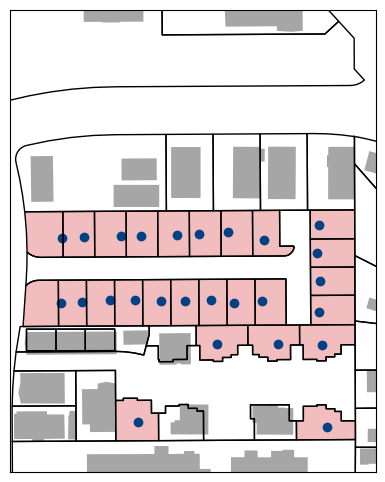

In [ ]:
### PLOTTING -- FIND EXAMPLES OF SPECIFIC MERGE CASES
## THIS CODE WOULD NOT BE RELEVANT OUTSIDE OF HAYWARD DUE TO HARD CODED APN VALUES

counter = 1

# Find instances without footprints
parcels_w_ftpt_apn = list(footprints_filtered['APN_PQ'].unique())
parcels_wo_ftpt = parcels_clean[~parcels_clean['APN_PQ'].isin(parcels_w_ftpt_apn)]
address_wo_ftpt = address_merge[~address_merge['APN_PQ'].isin(parcels_w_ftpt_apn)]

fig, ax = plt.subplots(1,1, figsize = (6,6))
parcels_wo_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:red', alpha = 0.3)
footprints_orig.copy().to_crs(crs_plot).plot(ax=ax, color = 'gray', alpha = 0.7)
address_wo_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = '#034185')
parcels.copy().to_crs(crs_plot).plot(ax=ax, edgecolor = 'black', facecolor = 'none')

ax.set_ylim(37.6463, 37.6481)
ax.set_xlim(-122.0811, -122.0793)

# Set tick marks for x axis 
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

# Add a legend
legend_patches = [
    mpatches.Patch(edgecolor='black', facecolor='none', label='Parcels'),
    mpatches.Patch(color='tab:red', alpha = 0.3, label='Parcels with no Footprint'),
    mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points in Parcels with no Footprint')
]

ax.legend(handles=legend_patches, loc = 'upper left', fontsize = 10)

# ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels

# plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
# plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
counter += 1
# plt.close()




# # One address, one footprint
# apn1 = '452-0004-060-00'

# # One address, multiple footprints
# apn2 = '444-0048-035-00'
# apn4 = '464-0085-024-00'
# apn5 = '464-0080-001-02'

# # MH Park
# apn3 = '464-0120-001-05'


# for apn_plt in [apn1, apn2]:

#     point_plt = address_merge[address_merge['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     parcel_plt = parcels_clean[parcels_clean['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     ftpt_plt = footprints_filtered[footprints_filtered['APN_PQ']==apn_plt].copy().to_crs(crs_plot)

#     fig, ax = plt.subplots(1,1, figsize = (6,6))
#     ftpt_plt.plot(ax=ax, color='gray', alpha = 0.7)
#     point_plt.plot(ax=ax, color = '#034185')
#     parcel_plt.plot(ax=ax, edgecolor = 'black', facecolor = 'none')

#     # ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks
#     ax.set_xticks([])  # Remove x-axis ticks
#     ax.set_yticks([])  # Remove y-axis ticks
#     ax.set_xticklabels([])  # Remove x-axis labels
#     ax.set_yticklabels([])  # Remove y-axis labels

#     # Legend
#     legend_patches = [
#     mpatches.Patch(edgecolor='black', facecolor='none', label='Parcel'),
#     mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
#     mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points')
#     ]

#     ax.legend(handles=legend_patches, loc = 'lower right', fontsize = 11)
#     plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
#     plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
#     counter += 1
    
#     plt.close()

# for apn_plt in [apn3]:

#     point_plt = address_merge[address_merge['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     parcel_plt = parcels_clean[parcels_clean['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     ftpt_plt = footprints_filtered[footprints_filtered['APN_PQ']==apn_plt].copy().to_crs(crs_plot)

#     fig, ax = plt.subplots(1,1, figsize = (6,6))
#     ftpt_plt.plot(ax=ax, color='gray', alpha = 0.7)
#     point_plt.plot(ax=ax, color='#034185', markersize = 10)
#     parcel_plt.plot(ax=ax, edgecolor = 'black', facecolor = 'none')

#     # ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks
#     ax.set_xticks([])  # Remove x-axis ticks
#     ax.set_yticks([])  # Remove y-axis ticks
#     ax.set_xticklabels([])  # Remove x-axis labels
#     ax.set_yticklabels([])  # Remove y-axis labels

#     # Legend
#     legend_patches = [
#     mpatches.Patch(edgecolor='black', facecolor='none', label='Parcel'),
#     mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
#     mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points')
#     ]

#     ax.legend(handles=legend_patches, loc = 'lower left', fontsize = 11)

#     plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
#     plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
    
#     plt.close()

46979    33042
Name: FootprintID, dtype: int64


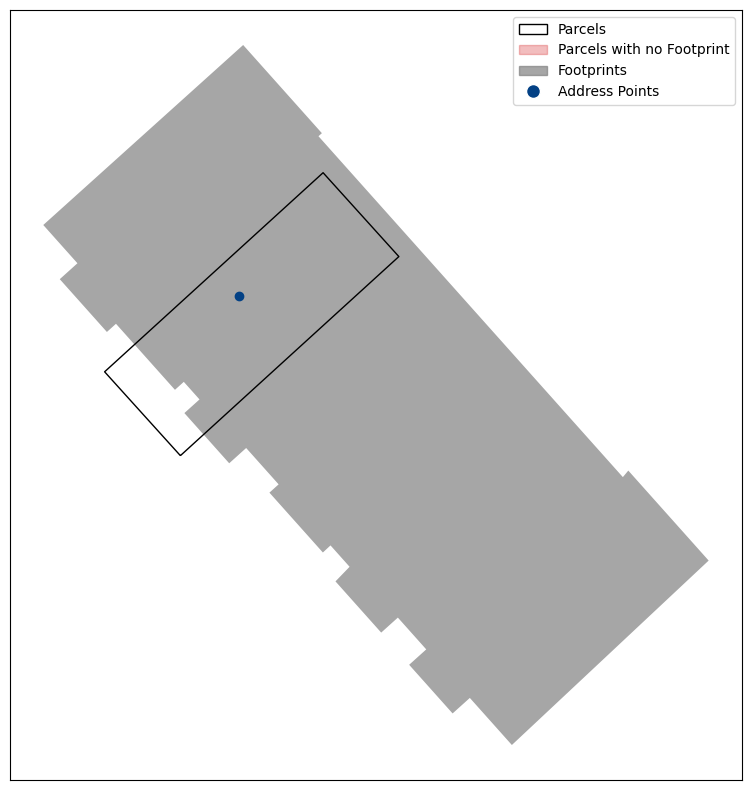

In [23]:
### PLOTTING -- FIND EXAMPLES OF SPECIFIC MERGE CASES
## THIS CODE WOULD NOT BE RELEVANT OUTSIDE OF HAYWARD DUE TO HARD CODED APN VALUES

counter = 1

# Find instances without footprints
parcels_w_ftpt_apn = list(footprints_filtered['APN_PQ'].unique())
parcels_wo_ftpt = parcels_clean[~parcels_clean['APN_PQ'].isin(parcels_w_ftpt_apn)]
address_wo_ftpt = address_merge[~address_merge['APN_PQ'].isin(parcels_w_ftpt_apn)]

fig, ax = plt.subplots(1,1, figsize = (6,6))
parcels_wo_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:red', alpha = 0.3)
footprints_orig.copy().to_crs(crs_plot).plot(ax=ax, color = 'gray', alpha = 0.7)
address_wo_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = '#034185')
parcels.copy().to_crs(crs_plot).plot(ax=ax, edgecolor = 'black', facecolor = 'none')

ax.set_ylim(37.6463, 37.6481)
ax.set_xlim(-122.0811, -122.0793)

# Set tick marks for x axis 
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

# Add a legend
legend_patches = [
    mpatches.Patch(edgecolor='black', facecolor='none', label='Parcels'),
    mpatches.Patch(color='tab:red', alpha = 0.3, label='Parcels with no Footprint'),
    mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points in Parcels with no Footprint')
]

ax.legend(handles=legend_patches, loc = 'upper left', fontsize = 10)

# ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels

plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
counter += 1
plt.close()






## UPDATED
# Case 1
apn1 = '452-0004-060-00'

# Case 2
apn2 = '444-0048-035-00'

# Case 3
# apn3 = '431-0106-062-00' TWO ADDRESS POINTS
apn3 = '431-0106-063-00' # SAME BLDG, ONE ADDRESS POINT

# Case 3
apn4 = '427-0036-042-01'

# Case 4
apn5 = '427-0051-075-00' 

# Case 4: MH Park
apn6 = '464-0120-001-05'


# apn1 = '452-0080-013-00'

# # case5 = ['452-0084-054-00'
#         '452-0084-099-02'
#         '427-0001-019-01'
#         '427-0011-027-00'
#         '427-0016-036-00'
#         '427-0026-018-00']

# case6a = ['452-0084-060-00',
#         '452-0084-109-02',
#         '427-0006-046-00',
#         '427-0006-010-01',
#         '445-0050-007-00',
#         '427-0051-075-00',
#         '427-0051-079-01',
#         '416-0130-041-00',
#         '416-0140-066-01',
#         '427-0056-036-00',
#         '427-0056-022-06',
#         '415-0240-015-00',
#         '431-0092-061-02',
#         '432-0012-039-02',
#         '456-0102-126-00',
#         '456-0102-128-00']

# case6b = ['085A-6431-002-00',
#           '429-0082-003-00',
#           '085A-6428-011-00']

# case5_v2 = [
#     "427-0026-018-00",
#     "427-0026-061-00",
#     "427-0026-019-00",
#     "427-0026-022-00",
#     "427-0041-047-08",
#     "427-0036-042-01",
#     "427-0051-031-00",
#     "427-0061-076-00",
#     "427-0061-061-00",
#     "427-0061-011-02",
#     "427-0061-037-00",
#     "416-0140-056-00",
#     "427-0061-040-00",
#     "427-0061-046-00",
#     "427-0061-048-00",
#     "431-0004-052-00",
#     "425-0300-042-03",
#     "431-0040-038-00",
#     "431-0056-016-04",
#     "431-0052-118-00",
#     "431-0052-117-00",
#     "444-0012-010-00",
#     "431-0106-074-00",
#     "431-0106-068-00",
#     "431-0106-062-00",
#     "431-0106-056-00",
#     "431-0107-079-00",
#     "431-0107-084-00"
# ]


# for apn_plt in [apn1, apn2, apn3, apn4, apn5]:
for apn_plt in [apn3]:
    counter = 2
# for apn_plt in footprints_filtered[footprints_filtered['FootprintID']==33042]['APN_PQ'].to_list():

    point_plt = address_merge[address_merge['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
    parcel_plt = parcels_clean[parcels_clean['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
    ftpt_plt = footprints_filtered[footprints_filtered['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
    print(ftpt_plt['FootprintID'])

    fig, ax = plt.subplots(1,1, figsize = (10,10))
    ftpt_plt.plot(ax=ax, color='gray', alpha = 0.7)
    point_plt.plot(ax=ax, color = '#034185')
    parcel_plt.plot(ax=ax, edgecolor = 'black', facecolor = 'none')

    # ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    # ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels

    # ax.set_title(apn_plt)

    # # Legend
    # legend_patches = [
    # mpatches.Patch(edgecolor='black', facecolor='none', label='Parcel'),
    # mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
    # mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points')
    # ]

    # ax.legend(handles=legend_patches, loc = 'upper right', fontsize = 11)


    # Add a legend
    legend_patches = [
    mpatches.Patch(edgecolor='black', facecolor='none', label='Parcels'),
    mpatches.Patch(color='tab:red', alpha = 0.3, label='Parcels with no Footprint'),
    mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points')
    ]

    ax.legend(handles=legend_patches, loc = 'upper right', fontsize = 10)


    plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
    plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
    counter += 1
    plt.show()
    
    plt.close()

# for apn_plt in [apn6]:

#     point_plt = address_merge[address_merge['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     parcel_plt = parcels_clean[parcels_clean['APN_PQ']==apn_plt].copy().to_crs(crs_plot)
#     ftpt_plt = footprints_filtered[footprints_filtered['APN_PQ']==apn_plt].copy().to_crs(crs_plot)

#     fig, ax = plt.subplots(1,1, figsize = (6,6))
#     ftpt_plt.plot(ax=ax, color='gray', alpha = 0.7)
#     point_plt.plot(ax=ax, color='#034185', markersize = 10)
#     parcel_plt.plot(ax=ax, edgecolor = 'black', facecolor = 'none')

#     # ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
#     # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  # Adjust `nbins` as needed for fewer ticks
#     ax.set_xticks([])  # Remove x-axis ticks
#     ax.set_yticks([])  # Remove y-axis ticks
#     ax.set_xticklabels([])  # Remove x-axis labels
#     ax.set_yticklabels([])  # Remove y-axis labels

#     # # Legend
#     # legend_patches = [
#     # mpatches.Patch(edgecolor='black', facecolor='none', label='Parcel'),
#     # mpatches.Patch(color='gray', alpha = 0.7, label='Footprints'),
#     # mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#034185', markersize=10, label='Address Points')
#     # ]

#     # ax.legend(handles=legend_patches, loc = 'lower left', fontsize = 11)

#     plt.savefig(fig_dir + f"parcel_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
#     plt.savefig(fig_dir + f"parcel_attribution{counter}.png", dpi = 500,  bbox_inches='tight', pad_inches=0)
#     plt.close()

In [12]:
footprints_filtered[footprints_filtered['FootprintID']==33042]['APN_PQ'].to_list()

['431-0106-059-00',
 '431-0106-060-00',
 '431-0106-061-00',
 '431-0106-062-00',
 '431-0106-063-00',
 '431-0106-064-00']

In [7]:
# Load address data
address_merge = inv_local.json_to_gdf(dir_intermediate + 'Address_Merged.json',crs_main)

dropped = address_merge[address_merge['NoScrapedData']=='Point Not Within 10m of Footprint' ]

<Axes: >

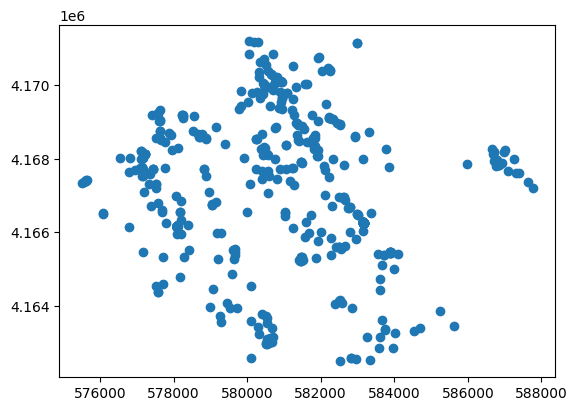

In [12]:
dropped.plot()

In [3]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in address_merge.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)
# for idx, row in dropped.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)

# display(m)

In [6]:
# Load address data
address_merge = inv_local.json_to_gdf(dir_intermediate + 'Address_Merged.json',crs_main)

In [7]:
address_merge

,geometry,OBJECTID,Address_ID,HouseNum,Prefix,Street_Name,Street_Type,Suffix_Dir,House_Unit,City,...,Num_Points,FootprintID,Scrape_Total_Value_Update,Scrape_Improvement_Value_Update,Scrape_Bldg_Area_Update,Scrape_Num_Units_Update,Scrape_Num_Bldg_Update,DataUpdate,Num_Addresses_Split,NoScrapedData
0,POINT (582731.978 4166406.386),111,46769,27503,E,10th,St,,,Hayward,...,1.0,NaN,0.0,0.0,0.0,1.0,1.0,Split Parcel Data Between Addresses - No Footp...,2.0,No Footprints Available in Parcel
1,POINT (582760.663 4166406.774),112,49178,27504,E,10th,St,,,Hayward,...,1.0,10800.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
2,POINT (582772.674 4166389.453),113,49179,27510,E,10th,St,,,Hayward,...,1.0,37191.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
3,POINT (582785.425 4166367.892),114,49175,27518,E,10th,St,,,Hayward,...,1.0,369.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
4,POINT (582797.735 4166347.432),115,49171,27526,E,10th,St,,,Hayward,...,1.0,8121.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62824,POINT (584924.023 4167106.582),82027,24443,28095,,Ziele Creek,Dr,,,Hayward,...,1.0,9971.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
62825,POINT (584934.844 4167098.031),82028,24424,28099,,Ziele Creek,Dr,,,Hayward,...,1.0,15306.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
62826,POINT (584947.565 4167095.398),82029,24431,28103,,Ziele Creek,Dr,,,Hayward,...,1.0,15878.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None
62827,POINT (584960.939 4167094.003),82030,24432,28107,,Ziele Creek,Dr,,,Hayward,...,1.0,15879.0,NaN,NaN,NaN,NaN,NaN,None,NaN,None


In [15]:
### MERGE ADDRESS POINTS WITH SCRAPED DATA ###

# Flag to determine if scaling is based on footprint area or building volumne 
use_height = True

# Loop through scraped data to populate dataframe 
print(len(scraped_merge), 'parcels total (looping through these now)')
for index, row in scraped_merge.iterrows():

    # Find the corresponding rows of addresses within the current parcel 
    gdf_index = address_merge[address_merge['APN_PQ'] == row['APN_PQ']].index
    group = address_merge.loc[gdf_index] 

    # Get footprints within parcel 
    parcel_ftpt = footprints_filtered[footprints_filtered['APN_PQ']==row['APN_PQ']]


    ### START RULESETS FOR MERGE ###


    # MANUSCRIPT CASE 5: NO FOOTPRINTS, ONE OR MORE ADDRESS POINT(S)
    if len(parcel_ftpt) == 0: 

         # One parcel and 1 address point, associate parcel and address point 
        if len(gdf_index) == 1:
            address_merge = inv_local.associate_scraped_data(address_merge.copy(), gdf_index, row, scraped_merge.columns)
            address_merge.loc[gdf_index, 'NoScrapedData'] = 'No Footprints Available in Parcel'

        # One parcel and several address points, split data between addresses 
        else: 
            factor = 1/len(gdf_index)
            address_merge = inv_local.associate_scraped_data(address_merge, gdf_index, row, scraped_merge.columns)
            address_merge.loc[gdf_index, 'Scrape_Total_Value_Update'] = row['Total_Value'] * factor
            address_merge.loc[gdf_index, 'Scrape_Improvement_Value_Update'] = row['Improvement_Value'] * factor
            address_merge.loc[gdf_index, 'Scrape_Bldg_Area_Update'] = row['Bldg_Area'] * factor
            address_merge.loc[gdf_index, 'Scrape_Num_Units_Update'] = (np.round(max(row['Num_Units'] * factor, 1)))
            address_merge.loc[gdf_index, 'Scrape_Num_Bldg_Update'] = (np.round(max(row['Num_Bldg'] * factor, 1)))
            address_merge.loc[gdf_index, 'DataUpdate'] = 'Split Parcel Data Between Addresses - No Footprints Available in Parcel'
            address_merge.loc[gdf_index, 'Num_Addresses_Split'] = len(gdf_index)
            address_merge.loc[gdf_index, 'NoScrapedData'] = 'No Footprints Available in Parcel'


    
    # There are footprints available in the parcel
    else: 

        # ONE PARCEL, ONE ADDRESS POINT 
        if len(gdf_index) == 1:

            # Associate parcel and address point 
            address_merge = inv_local.associate_scraped_data(address_merge.copy(), gdf_index, row, scraped_merge.columns)
        
            # MANUSCRIPT CASE 1: ONE FOOTPRINT, ONE ADDRESS POINT: Associate address point and parcel data to footprint, even if not intersecting 
            if len(parcel_ftpt) == 1:
                address_merge.loc[gdf_index, 'FootprintID'] = parcel_ftpt['FootprintID'].values[0]

            # MANUSCRIPT CASE 2: MULTIPLE FOOTPRINTS, ONE ADDRESS POINT: Associate address point and parcel data to closest footprint 
            elif (len(parcel_ftpt) > 1):
                
                # Spatial join address and footprints 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','geometry']], how="left", predicate='within')

                # If address not directly within a footprint, locate closest footprint
                if np.isnan(address_with_ftpt['FootprintID_right'].values[0]): 
                    address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                    address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['ClosestFtpt_ID'].values[0]
                        
                # If address is directly wihtin a footprint, associate address with footprint  
                else: 
                    address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['FootprintID_right'].values[0]



        # Multiple Address Points associated with Parcel 
        elif len(gdf_index) > 1:

            # Merge and associate footprints 
            if use_height: 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','FootprintArea','FootprintHeight','geometry']], how="left", predicate='within')
            else: 
                address_with_ftpt = gpd.sjoin(group, parcel_ftpt[['FootprintID','FootprintArea','geometry']], how="left", predicate='within')
            address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt['FootprintID_right'].values

            # Check if there are accessory dwelling units present in the parcel 
            adu_index = group[group['FeatureCode'] == 'Single-Family Dwelling Accessory Suite'].index




            # If no ADUs present in the parcel 
            if len(adu_index) == 0: 

                # MANUSCRIPT CASE 3: 1 OR MORE FOOTPRINTS, MULTIPLE POINTS, ALL POINTS WITHIN FOOTPRINT(S)
                # If all points are within footprints, associate parcel information with one point per footprint for later use, making notes for all other points 
                if address_with_ftpt.loc[gdf_index, 'FootprintID_right'].notna().all():
                    address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, gdf_index, row, scraped_merge.columns, address_with_ftpt, 'FootprintID_right', use_height)
                
                # MANUSCRIPT CASE 4: 1 OR MORE FOOTPRINTS, MULTIPLE POINTS, SOME OR ALL POINTS NOT INTERSECTING WITH FOOTPRINT(S)
                # If some or all points are not located within a footprint
                else:

                    # Find the nearest footprint for each non-ADU address
                    address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                    address_with_ftpt_close_idx = address_with_ftpt[address_with_ftpt['DistanceToFtpt'] <= 10].index
                    address_with_ftpt_far_idx = address_with_ftpt[address_with_ftpt['DistanceToFtpt'] > 10].index

                    # If there are no points close to a building footprint, associate data with closest footprint regardless
                    if len(address_with_ftpt_close_idx) == 0: 
                
                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[gdf_index, 'FootprintID'] = address_with_ftpt.loc[gdf_index, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points
                            address_merge.loc[gdf_index, 'NoScrapedData'] = 'Has Scraped Data, but 10m Away - No Close Points'   
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, gdf_index, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)

                    
                    # If there are some points close to building footprints, associate addresses to closest footprints, associate parcel with all footprints containing data 
                    else:    

                        # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                        address_merge.loc[address_with_ftpt_close_idx, 'FootprintID'] = address_with_ftpt.loc[address_with_ftpt_close_idx, 'ClosestFtpt_ID'].values
                        address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)
                     
                        # Associate information with one point per footprint, making notes for all other points 
                        address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, address_with_ftpt_close_idx, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)
                        address_merge.loc[address_with_ftpt_far_idx, 'NoScrapedData'] = 'Point Not Within 10m of Footprint'  
                

            # REPEAT LOGIC, BUT WITH LOGIC TO HANDLE ADUs IN DATA
            else:

                # Find non-ADU points
                non_adu_indices = group[group['FeatureCode'] != 'Single-Family Dwelling Accessory Suite'].index

                # If parcel has ADU(s) and only one non-ADU point, associate data with non-ADU address. This is the same as the one address, one footprint method above (MANUSCRIPT CASE 1)
                if len(non_adu_indices) == 1: 
                    
                    # Associate parcel and non-ADU address point, make notes for ADU points
                    address_merge = inv_local.associate_scraped_data(address_merge.copy(), non_adu_indices, row, scraped_merge.columns)
                    address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'  

                    # If non-ADU unit does not have a footprint, update with closest footprint
                    if np.isnan(address_with_ftpt.loc[non_adu_indices, 'FootprintID_right'].values[0]): 
                        address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                        address_merge.loc[non_adu_indices, 'FootprintID'] = address_with_ftpt.loc[non_adu_indices, 'ClosestFtpt_ID'].values[0]
                    
                # If parcel has ADU(s) and more than one non-ADU point
                elif len(non_adu_indices) > 1: 

                    # If parcel contains ADU(s), and all non-ADU points are within a footprint (MANUSCRIPT, CASE 3)
                    if address_with_ftpt.loc[non_adu_indices, 'FootprintID_right'].notna().all():
                                                
                        # Associate information with one point per footprint, making notes for all other points 
                        address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, non_adu_indices, row, scraped_merge.columns, address_with_ftpt, 'FootprintID_right', use_height)
                        address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'                     

                    # If parcel contains ADU(s), and some or all non-ADU points are not located within a footprint (MANUSCRIPT CASE 4)
                    else:
                    
                        # Find the nearest footprint for each non-ADU address 
                        address_with_ftpt = inv_local.find_nearest(address_with_ftpt, parcel_ftpt)
                        non_adu = address_with_ftpt.loc[non_adu_indices]
                        address_with_ftpt_close_idx = non_adu[non_adu['DistanceToFtpt'] <= 10].index
                        address_with_ftpt_far_idx = non_adu[non_adu['DistanceToFtpt'] > 10].index

                        # If there are no address points close to footprints
                        if len(address_with_ftpt_close_idx) == 0: 

                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[non_adu, 'FootprintID'] = address_with_ftpt.loc[non_adu, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points 
                            address_merge.loc[non_adu, 'NoScrapedData'] = 'Has Scraped Data, but 10m Away - No Close Points' 
                            address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure'  
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, non_adu, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)

                        # If there are some address points close to footprints
                        else:    
                            # Reset footprints and building area for cases where data is close and map appropriate information to address_with_ftpt
                            address_merge.loc[address_with_ftpt_close_idx, 'FootprintID'] = address_with_ftpt.loc[address_with_ftpt_close_idx, 'ClosestFtpt_ID'].values
                            address_with_ftpt = inv_local.map_closest_footprints(address_with_ftpt.copy(), footprints_orig, use_height)

                            # Associate information with one point per footprint, making notes for all other points 
                            address_merge, drop_idx = inv_local.associate_scraped_split_multiple_addresses(address_merge, address_with_ftpt_close_idx, row, scraped_merge.columns, address_with_ftpt, 'ClosestFtpt_ID', use_height)
                            address_merge.loc[address_with_ftpt_far_idx, 'NoScrapedData'] = 'Point Not Within 10m of Footprint'  
                            address_merge.loc[adu_index, 'NoScrapedData'] = 'Scraped Data Associated with Non-ADU Structure' 
                    
                # Only ADU points present in the parcel
                else: 
                    # NOTE: This case only appears once in Hayward. More robust code may be needed if there are additional cases
                    address_merge = inv_local.associate_scraped_data(address_merge, gdf_index[0], row, scraped_merge.columns)
                    address_merge.loc[gdf_index[1:], 'NoScrapedData'] = 'Duplicate Address within Parcel / Footprint'  
                    address_merge.loc[gdf_index[0], 'FC_Updated'] = 'Single Family Residential - Converted from Only ADU'

            
    if index % 1000 == 0: 
        print(index, 'parcels assessed')
    
# Ensure all footprint values are numeric 
address_merge.loc[:,'FootprintID'] = pd.to_numeric(address_merge['FootprintID'], errors='coerce')

# Export footprint-level inventory
inv_local.gdf_to_json(address_merge, dir_intermediate + 'Address_Merged.json')

39643 parcels total (looping through these now)
0 parcels assessed
1000 parcels assessed
2000 parcels assessed
3000 parcels assessed
4000 parcels assessed
5000 parcels assessed
6000 parcels assessed
7000 parcels assessed
8000 parcels assessed
9000 parcels assessed
10000 parcels assessed
11000 parcels assessed
12000 parcels assessed
13000 parcels assessed
14000 parcels assessed
15000 parcels assessed
16000 parcels assessed
17000 parcels assessed
18000 parcels assessed
19000 parcels assessed
20000 parcels assessed
21000 parcels assessed
22000 parcels assessed
23000 parcels assessed
24000 parcels assessed
25000 parcels assessed
26000 parcels assessed
27000 parcels assessed
28000 parcels assessed
29000 parcels assessed
30000 parcels assessed
31000 parcels assessed
32000 parcels assessed
33000 parcels assessed
34000 parcels assessed
35000 parcels assessed
36000 parcels assessed
37000 parcels assessed
38000 parcels assessed
39000 parcels assessed
JSON File Saved


## **SECTION 5: Convert Merged Addresses into Footprint-Level Inventory**

In [32]:
# Load address data
address_merge = inv_local.json_to_gdf(dir_intermediate + 'Address_Merged.json',crs_main)
print('Total Address Points:', len(address_merge))
address_scraped = address_merge[address_merge['ScrapeFlag']==1]
print('Scraped Address Points:', len(address_scraped))

# Load parcels and parcel-level tax data and merge 
parcels_clean = inv_local.json_to_gdf(dir_intermediate + 'Scraped_Parcels.json',crs_main)
scraped_merge = pd.read_csv('./Input_Data/Local/Additional_Parcel_Information.csv', low_memory=False)
parcels = parcels_clean.merge(scraped_merge, on='APN_PQ', how='inner')

# Load footprints
footprints_filtered = inv_local.json_to_gdf(dir_intermediate + 'Footprints_with_Parcels_Filtered.json',crs_main)
footprints_orig = inv_local.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json',crs_main)

# Assess if there are any parcels that do not have associated address points 
parcels_associated = address_scraped['APN_PQ'].unique().tolist()
parcels_unassociated = parcels[~parcels['APN_PQ'].isin(parcels_associated)]
if len(parcels_unassociated) > 0: 
    raise ValueError('Unassociated Parcels -- Check that all parcel data has an associated address point')

Total Address Points: 62829
Scraped Address Points: 42254


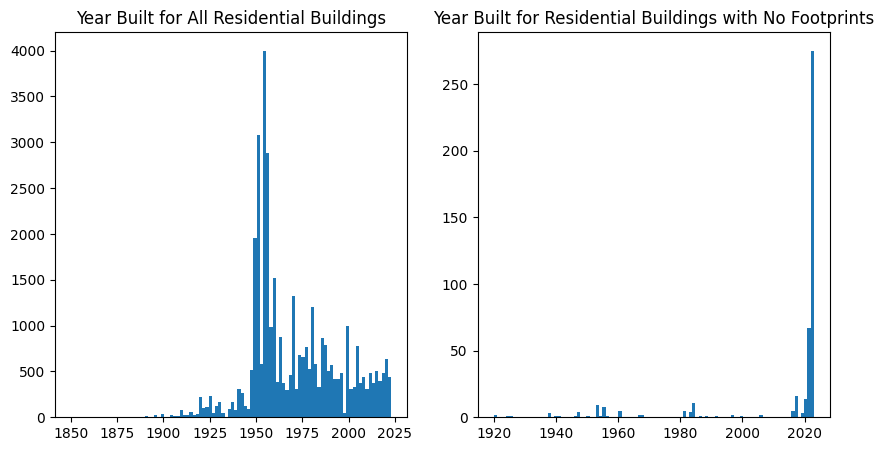

In [33]:
# Examine cases with no footprints in the parcel 
noftpt = address_merge[address_merge['NoScrapedData']=='No Footprints Available in Parcel']
fig, ax = plt.subplots(1,2, figsize = (10, 5))
ax[0].hist(address_merge['Scrape_Year_Built'], bins = 100)
ax[0].set_title('Year Built for All Residential Buildings')
ax[1].hist(noftpt['Scrape_Year_Built'], bins = 100)
ax[1].set_title('Year Built for Residential Buildings with No Footprints')
plt.show()

In [34]:
#### Prepare address_merge - drop data that is not helpful for footprint inventory, drop appropriate columns, update values ####

# Remove address points that are duplicated within a footprint  - these can get dropped because all of these footprints are covered by a different address point 
address_merge_filter = address_merge[address_merge['NoScrapedData']!='Duplicate Address within Parcel / Footprint']

# Remove address points that too far from footprints  - none of these points have footprints associatd with them. They can get dropped in footprint level inventory 
address_merge_filter = address_merge_filter[address_merge_filter['NoScrapedData']!='Point Not Within 10m of Footprint']

# Remove address points where there are no footprints in the parcel - these do not belong in footprint-based inventory. Most are new construction that does not have footprints - retain these and add back in 
no_ftpt_in_parcel = address_merge_filter[address_merge_filter['NoScrapedData']=='No Footprints Available in Parcel']
address_merge_filter = address_merge_filter[address_merge_filter['NoScrapedData']!='No Footprints Available in Parcel']

# Keep only AUD points that are within their own unique footprint (remove duplciated AUD points and AUDs not within footprints) 
duplicate_ftpt = address_merge_filter[address_merge_filter.duplicated(subset='FootprintID', keep=False)]
aud_drop_idx = duplicate_ftpt[duplicate_ftpt['NoScrapedData']=='Scraped Data Associated with Non-ADU Structure'].index
address_merge_filter = address_merge_filter.drop(index=aud_drop_idx)

# Update appropriate columns 
address_merge_filter['Scrape_Total_Value'] = address_merge_filter['Scrape_Total_Value_Update'].where(address_merge_filter['Scrape_Total_Value_Update'].notna(), address_merge_filter['Scrape_Total_Value'])
address_merge_filter['Scrape_Improvement_Value'] = address_merge_filter['Scrape_Improvement_Value_Update'].where(address_merge_filter['Scrape_Improvement_Value_Update'].notna(), address_merge_filter['Scrape_Improvement_Value'])
address_merge_filter['Scrape_Bldg_Area'] = address_merge_filter['Scrape_Bldg_Area_Update'].where(address_merge_filter['Scrape_Bldg_Area_Update'].notna(), address_merge_filter['Scrape_Bldg_Area'])
address_merge_filter['Scrape_Num_Units'] = address_merge_filter['Scrape_Num_Units_Update'].where(address_merge_filter['Scrape_Num_Units_Update'].notna(), address_merge_filter['Scrape_Num_Units'])
address_merge_filter['Scrape_Num_Bldg'] = address_merge_filter['Scrape_Num_Bldg_Update'].where(address_merge_filter['Scrape_Num_Bldg_Update'].notna(), address_merge_filter['Scrape_Num_Bldg'])
address_merge_filter['Address_ID'] = address_merge_filter['AddressID_Updated'].where(address_merge_filter['AddressID_Updated'].notna(), address_merge_filter['Address_ID'])
address_merge_filter['FeatureCode'] = address_merge_filter['FC_Updated'].where(address_merge_filter['FC_Updated'].notna(), address_merge_filter['FeatureCode'])
address_merge_filter = address_merge_filter.drop(columns=['Scrape_Total_Value_Update', 'Scrape_Improvement_Value_Update', 'Scrape_Bldg_Area_Update', 'Scrape_Num_Units_Update','Scrape_Num_Bldg_Update','AddressID_Updated', 'FC_Updated'])


# Drop appropriate columns 
drop = ['OBJECTID','HouseNum', 'Prefix', 'Street_Name', 'Street_Type', 'Suffix_Dir', 'House_Unit', 'City', 'State', 'Zipcode', 'FullAddress', 'AddrUnit_Type',
        'SubtypeField','Scrape_Bldg_Condition', 'Scrape_Bldg_Quality', 'ScrapeFlag','NoScrapedData','DataUpdate', 'Num_Addresses_Split', 'Scrape_Num_Bldg', 'CensusBlock','CensusTract',
        'APN_PQ','LonTxt_X','LatTxt_Y']
address_merge_filter = address_merge_filter.drop(columns = drop)

# Drop appropriate columns for cases with no footprints in parcel, other than CensusBlock and CensusTract
drop_no_ftpt = ['Scrape_Total_Value_Update', 'Scrape_Improvement_Value_Update', 'Scrape_Bldg_Area_Update', 'Scrape_Num_Units_Update','Scrape_Num_Bldg_Update','AddressID_Updated', 'FC_Updated', 
                'OBJECTID','HouseNum', 'Prefix', 'Street_Name', 'Street_Type', 'Suffix_Dir', 'House_Unit', 'City', 'State', 'Zipcode', 'FullAddress', 'AddrUnit_Type',
                'SubtypeField','Scrape_Bldg_Condition', 'Scrape_Bldg_Quality','NoScrapedData','DataUpdate', 'Num_Addresses_Split', 'Scrape_Num_Bldg',
                'APN_PQ','LonTxt_X','LatTxt_Y']
no_ftpt_in_parcel = no_ftpt_in_parcel.drop(columns = drop_no_ftpt)

In [35]:
#### BUILD FOOTPRINT-LEVEL INVENTORY - FIRST: Address cases with unique parcel/footprint pairings (no conflict between footprints) ####

# Find unique cases
unique_ftpt_addresses = address_merge_filter.drop_duplicates(subset='FootprintID', keep = False)
unique_ftpt_addresses = unique_ftpt_addresses.drop(columns =['geometry'])
unique_ftpt_addresses.loc[:,'Local_Flag'] = 1
print('Unique Footprints:', len(unique_ftpt_addresses))

# Create baseline inventory 
ftpt_inv = footprints_orig.copy()
orig_inv_length = len(ftpt_inv)

# Merge unique footprint information in with baseline footprint inventory and perform checks for dropped points
ftpt_inv = ftpt_inv.merge(unique_ftpt_addresses, on='FootprintID', how='left')
ftpt_inv = gpd.GeoDataFrame(ftpt_inv, geometry='geometry', crs=address_merge.crs)
if len(ftpt_inv) != orig_inv_length: 
    raise ValueError('Footprints Dropped - Step 1')

if len(ftpt_inv[ftpt_inv['Local_Flag']==1]) != len(unique_ftpt_addresses): 
    raise ValueError('Footprints Dropped - Step 2')

Unique Footprints: 32283


In [36]:
#### BUILD FOOTPRINT-LEVEL INVENTORY - SECOND: Address cases with multiple parcels within a footprint ####

# Now find footprints that are not nonunique (multiple points or parcels are within one footprint)
nonunique_ftpt_addresses = address_merge_filter[address_merge_filter.duplicated(subset='FootprintID', keep=False)]

# Group by footprints and loop through data 
counter = 0
ftpt_groups = nonunique_ftpt_addresses.groupby('FootprintID')
print('Footprints with Multiple Parcels:', len(ftpt_groups), '(looping through these now)')


idx_to_drop = []
rows_to_add = gpd.GeoDataFrame(columns=ftpt_inv.columns, geometry=ftpt_inv.geometry.name, crs=ftpt_inv.crs)


for ftpt_id, group in ftpt_groups: 

    # Define which columns should be combined by storing lists of values (list_columns), and which should be combined by summing (sum_columns)
    # NOTE: In Hayward, the Scrape_Num_Units is handled in a way that is appropriate for the Hayward case and is not included in any of these. This
    # may need to be modified if this script is used elsewhere. 
    list_columns = ['Address_ID','FeatureCode','Scrape_Use_Description','Scrape_Use_Code', 'Scrape_Landslide', 'Scrape_Liquefaction', 'Scrape_Fault_Zone',
                        'Scrape_Homeowner_Exemption', 'Scrape_Year_Built','Scrape_Eff_Year_Built', 'Scrape_Bldg_Class', 'Scrape_Construction','Scrape_Num_Stories','Scrape_Parking']
    
    sum_columns = ['Scrape_Total_Value', 'Scrape_Improvement_Value','Scrape_Bldg_Area', 'Num_Points']
    
    ftpt_cols = ['FootprintArea', 'FootprintHeight', 'CensusBlock', 'CensusTract', 'FootprintID']

    # Update row in footprint inventory corresponding to multiple addresses
    updated_row, drop_idx = inv_local.merge_addresses_into_footprint(ftpt_inv.copy(), list_columns, sum_columns, ftpt_cols, ftpt_id, group, local_flag = 2, ftpt_id_column = 'FootprintID')

    #  Drop original row in gdf 
    idx_to_drop.append(drop_idx)

    # Append new row 
    rows_to_add = pd.concat([rows_to_add, updated_row], ignore_index=True)

    # Report progress      
    counter += 1
    if counter % 100 == 0: 
        print(counter)  

# Drop apporpriate index values from the gdf and concatenate updated rows 
ftpt_inv = ftpt_inv.drop(index = [i[0] for i in idx_to_drop]) # Flatten tuple values for .drop to work 
ftpt_inv = pd.concat([ftpt_inv, rows_to_add], ignore_index=True)

# Ensure all geometries are set equal to the footprint geometries
merged_gdf = ftpt_inv.merge(footprints_orig[['FootprintID', 'geometry']], on='FootprintID', suffixes=('', '_new'))
ftpt_inv['geometry'] = merged_gdf['geometry_new']

# Fill in empty Local_Flag entires
ftpt_inv['Local_Flag'] = ftpt_inv['Local_Flag'].map(lambda x: 0 if x == np.nan else x)

# Export footprint inventory 
inv_local.gdf_to_json(ftpt_inv, dir_intermediate + 'Local_Inventory_Polygon.json')


Footprints with Multiple Parcels: 1522 (looping through these now)
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
JSON File Saved


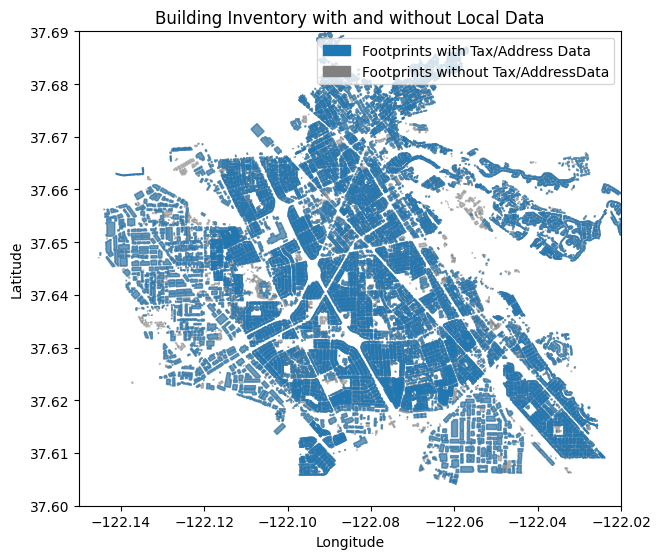

In [37]:
# Create figure and axis for the plot
if True: 
    fig, ax = plt.subplots(figsize=(7,7))
    ftpt_inv.to_crs(crs_plot).plot(ax=ax, color='gray', edgecolor='gray', alpha=0.5, label = 'All Footprints')
    ftpt_inv[ftpt_inv['Local_Flag']>0].to_crs(crs_plot).plot(ax=ax, color='tab:blue', edgecolor='tab:blue', alpha=0.5)
    plt.title('Building Inventory with and without Local Data')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.xlim(xbounds)
    plt.ylim(ybounds)
    handles = [
    mpatches.Patch(color='tab:blue', label='Footprints with Tax/Address Data'),
    mpatches.Patch(color='gray', label='Footprints without Tax/AddressData')]
    ax.legend(handles=handles)
    plt.show()

In [38]:
### DEAL WITH PARCELS THAT DO NOT HAVE FOOTPRINTS

# Set Footprint_Flag for points with no footprints 
no_ftpt_in_parcel['Footprint_Flag'] = 0

# Prepare data without footprints for merge
no_ftpt_in_parcel = no_ftpt_in_parcel.drop(columns =['ScrapeFlag'])
no_ftpt_in_parcel['Local_Flag'] = 3
no_ftpt_in_parcel['Scrape_Year_Built'] = no_ftpt_in_parcel['Scrape_Year_Built'].fillna(np.nan)

# Drop points that do not have a footprint and do not have a year built - most of these seem to be planning development parcels based on spot checks in google maps 
no_ftpt_in_parcel = no_ftpt_in_parcel[no_ftpt_in_parcel['Scrape_Year_Built'].notna()]

# Group address points based on likely being in same building (based on 7m distance limit, which was selected through Hayward trial and error)
no_ftpt_in_parcel = inv_local.list_nearby_address_ids(no_ftpt_in_parcel)
no_ftpt_in_parcel = inv_local.find_groups(no_ftpt_in_parcel)

### ADDRESS UNIQUE POINTS THAT DO NOT HAVE FOOTPRINTS ###
# Find unique cases (address points that are likely not sharing a footprint)
unique_no_ftpt = no_ftpt_in_parcel.drop_duplicates(subset='GroupID', keep = False)
unique_no_ftpt = unique_no_ftpt.drop(columns =['Within_Limit', 'Nearby_AddressIDs', 'GroupID'])
print('Unique Points with no Footprint:', len(unique_no_ftpt))


Unique Points with no Footprint: 230


In [39]:
### ADDRESS GROUPED POINTS THAT DO NOT HAVE FOOTPRINTS ###

# Merge address points into likely footprint groups, using the same method as case with multiple parcels within same footprint 
nonunique_no_ftpt = no_ftpt_in_parcel[no_ftpt_in_parcel.duplicated(subset='GroupID', keep=False)]
no_ftpt_groups = nonunique_no_ftpt.groupby('GroupID')
print('Likely Groups with Multiple Points:', len(no_ftpt_groups))

# Initialize gdf
nonunique_no_ftpt_updated = gpd.GeoDataFrame(columns=nonunique_no_ftpt.columns, geometry=nonunique_no_ftpt.geometry.name, crs=nonunique_no_ftpt.crs)

for group_id, group in no_ftpt_groups: 

    # Define which columns should be combined by storing lists of values, and which should be combined by summing 
    list_columns = ['Address_ID','FeatureCode','Scrape_Use_Description','Scrape_Use_Code', 'Scrape_Landslide', 'Scrape_Liquefaction', 'Scrape_Fault_Zone',
                        'Scrape_Homeowner_Exemption', 'Scrape_Year_Built','Scrape_Eff_Year_Built', 'Scrape_Bldg_Class', 'Scrape_Construction','Scrape_Num_Stories','Scrape_Parking']
    
    sum_columns = ['Scrape_Total_Value', 'Scrape_Improvement_Value','Scrape_Bldg_Area', 'Num_Points']

    # Update row to contain multiple addresses
    updated_row = inv_local.merge_addresses_into_missing_footprint(list_columns, sum_columns, group)

    # Append new row 
    nonunique_no_ftpt_updated = pd.concat([nonunique_no_ftpt_updated, updated_row], ignore_index=True)

# Drop appropriate rows
nonunique_no_ftpt_updated = nonunique_no_ftpt_updated.drop(columns = ['Within_Limit', 'Nearby_AddressIDs', 'GroupID'])


Likely Groups with Multiple Points: 19


In [40]:
### RECOMBINE INVENTORIES TO MAKE POINT-BASED INVENTORY ###

# Recombine cases with no footprints
no_ftpt = pd.concat([unique_no_ftpt, nonunique_no_ftpt_updated], ignore_index=True)

# Create artificial FootprintID for parcels with no footpirnts values starting at 100,000
no_ftpt['FootprintID'] = np.arange(100000, 100000 + len(no_ftpt))
no_ftpt['Local_Flag'] = 3 # Rows do have local data
no_ftpt['Footprint_Flag'] = 0 # Rows do not have footprint

# Modify footprint inventory geometry to be the centroid of each footprint 
ftpt_inv = ftpt_inv.rename(columns={'geometry': 'ftpt_geometry'})
ftpt_inv['geometry'] = ftpt_inv['ftpt_geometry'].centroid
ftpt_inv.set_geometry('geometry')
ftpt_inv['Footprint_Flag'] = 1
print(len(no_ftpt))

# Merge points into footprint-based inventory
ftpt_inv_point = pd.concat([ftpt_inv, no_ftpt], ignore_index=True)

# Save inventory 
inv_local.gdf_to_json(ftpt_inv_point, dir_intermediate + 'Local_Inventory_Point.json')

249
JSON File Saved


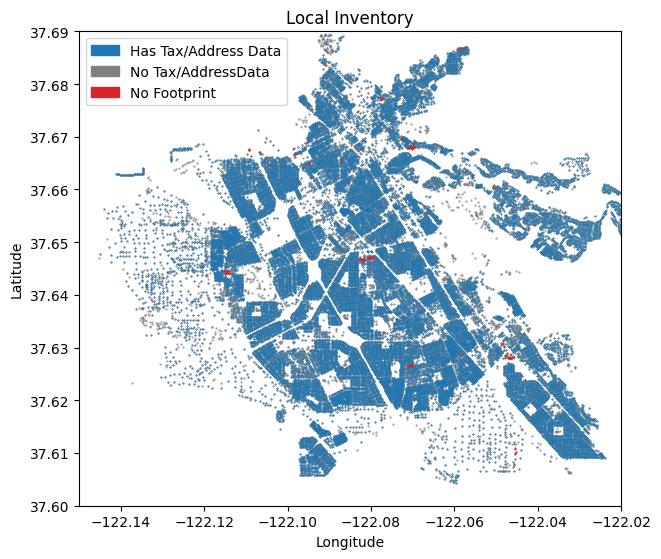

In [41]:
# Create figure and axis for the plot
if True: 
    fig, ax = plt.subplots(figsize=(7,7))
    ftpt_inv_point.to_crs(crs_plot).plot(ax=ax, color='gray', markersize=0.2, label='All Footprints')
    scraped = ftpt_inv_point[ftpt_inv_point['Local_Flag']>0]
    scraped[scraped['Footprint_Flag']==1].to_crs(crs_plot).plot(ax=ax, color='tab:blue', markersize=0.1)
    scraped[scraped['Footprint_Flag']==0].to_crs(crs_plot).plot(ax=ax, color='tab:red', markersize=0.1)
    plt.title('Local Inventory')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.xlim(xbounds)
    plt.ylim(ybounds)
    handles = [
    mpatches.Patch(color='tab:blue', label='Has Tax/Address Data'),
    mpatches.Patch(color='gray', label='No Tax/AddressData'),
    mpatches.Patch(color='tab:red', label='No Footprint')]
    ax.legend(handles=handles)
    plt.show()

## **SECTION 6: Map Features to Corresponding NSI Ontology for Occupancy Class**

In [42]:
### CONVERT TO NSI ###

# NAICS CODES https://www.census.gov/naics/?input=22&chart=2022&details=221310

# NAICS Codes are based on business classification - not the same as building classification 

# Define map between Address Point Feature Code and NSI 
fc_map = {
    np.nan : None,
    'Single-Family Dwelling' : 'RES1', 
    'Duplex' : 'RES3A',
    'Single Family Residence with addressed ADU': 'RES1',
    'Single-Family Dwelling Accessory Suite': 'RES1',
    'Multi-Family Lot, Single Family Residence': 'RES1',
    'Multi-Family Dwelling, Apartment':'RES3',
    'Triplex':'RES3B',
    'Multi-Family Dwelling':'RES3',
    'Multi-Family Dwelling, Condominium':'RES3',
    'Fourplex':'RES3B',
    'Multi-Family Dwelling, Townhouse':'RES3',
    'Mobile Home Park': 'RES2',
    'Mobile / Modular / Manufactured Home': 'RES2',
    'Single Family Residence, Duet' : 'RES3A',
    'Institutional Residence / Dorm / Barracks': 'RES5',
    'Single Family Residence with non-addressed ADU':'RES3A',  
    'Single Family Residential - Converted from Only ADU' : 'RES1',
    'Airport Hangar' : 'COM4', # NAICS 488119 checked using Hazus document
    'Bank' : 'COM5',
    'Banking or Finance Facility' : 'COM5',
    'Building General' : 'UNK',
    'Building Shell' : 'UNK',
    'Business Park Office' : 'COM4',
    'Cellular Site' : 'NOTBLDG', #### DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Clubhouse / Community Building' : 'COM8',
    'College / University' : 'EDU2',
    'Commercial or Retail Facility' : 'COM1', 
    'Common Area' : 'NOTBLDG', 
    'Communication Tower' : 'NOTBLDG', # DIVERGE: NAICS 237130 (Power and Communication Lines) is classified as IND6, which is why there may be buildings in the roads. I chose to leave this as 'NOTBLDG' in this case 
    'Cooperative' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'County Government Facility' : 'GOV1',
    'Dairy' : 'AGR1',
    'Day Care Facility' : 'COM3', # NAICS 624410 checked using Hazus document 
    'Education Facility' : 'EDU1',
    'Electric Vehicle Charging Station' : 'NOTBLDG', # Didn't seem to have a clear NAICS code 
    'Electrical Meter' : 'NOTBLDG', # DIVERGE: NAICS 221122 (Electrical Power Distribution) is COM4, NAICS 334515 (Instrument Manufacturing for Electrical Signals) is IND2. I chose to leave thie as 'NOTBLDG' in this case
    'Energy Facility' : 'IND1',  # Depending on type of energy, NAICS codes designated as IND1 or IND2. Here, using IND1 
    'Fire Station / EMS Station' : 'GOV2', 
    'Fitness Center' : 'COM8', 
    'Gas Station': 'COM1', # NAICS 447110 checked using Hazus document
    'Gate' : 'NOTBLDG', 
    'Golf Course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Government or Military Facility' : 'GOV1',
    'Greenhouse / Nursery' : 'AGR1',
    'Grocery Store': 'COM1',
    'Health or Medical Facility' : 'COM7',
    'Hospital / Medical Center' : 'COM6',
    'Hotel / Motel' : 'RES4',
    'House of Worship': 'REL1',
    'Industrial Business Park' : 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Condominium': 'IND', # Insufficient specificity for more detailed designation 
    'Industrial Facility' : 'IND', # Insufficient specificity for more detailed designation 
    'Information or Communication Facility' : 'IND6', # NAICS 237130 checked using Hazus document 
    'Irrigation Controller' : 'COM4', # NAICS 221310 (Water Supply and Irrigation Systems) checked using Hazus document 
    'Library' :'GOV1', # DIVERGE: NAICS 519120 (Libraries and Archives) listed under COM4, but I thought it was more appropriate as a governemntal building 
    'Light Rail Station' : 'COM4', # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Motor Vehicle Dealer' : 'COM1',
    'Motor Vehicle Repair' : 'COM3',
    'Municipal Government Facility' : 'GOV1',
    'Nursing Home / Long Term Care' : 'RES6',
    'Park' : 'NOTBLDG',
    'Parking Lot' : 'NOTBLDG', # DIVERGE: NAICS 812930 (Parking Lots and Garages) classified as COM3. I chose to leave as 'NOTBLDG' in this case
    'Post Office' : 'GOV1',
    'Public Attraction or Landmark Building' : 'GOV1',
    'Public Pool' : 'NOTBLDG', # DIVERGE: NAICS 713940 (Fitness and recreational Sports Centers) listed under COM8. I chose to leave as 'NOTBLDG' in this case
    'Pump' : 'NOTBLDG', # DIVERGE: NAICS 333911 (Pump and Pumping Equipment Manufacturing) under IND1 and 221310 (Water Supply) under COM4. I chose to leave as 'NOTBLDG' in this case
    'Railroad Facility' : 'COM4',  # 485112 (Commeter Rail Systems) checked using Hazus document 
    'Railroad Maintenance / Fuel Facility' : 'COM4', # NAICS 488210 checked using Hazus document 
    'Recycling Facility' : 'COM4', # NAICS 562920 checked using Hazus document 
    'Restaurant / Eating Establishment' : 'COM1',
    'Rural / Open Space' : 'NOTBLDG',
    'School: Elementary' : 'EDU1',
    'Shopping Mall / Complex' : 'COM1',
    'State Government Facility' : 'GOV1',
    'Substation' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telecom Utility Box' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Telephone Facility' : 'NOTBLDG', # Several possible NAICS codes, but chose to leave as 'NOTBLDG' in this case 
    'Traffic Signal' : 'NOTBLDG',
    'Transportation Facility' : 'COM4', # NAICS 488490 (Support Activiies for Road Transportation) checked using Hazus document 
    'Trucking Firm' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant Land' : 'NOTBLDG',
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Warehouse (Retail / Wholesale)' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Water Meter' : 'NOTBLDG',
    'Water Tank' : 'NOTBLDG',
    'Water Treatment Facility' : 'GOV1' # DIVERGE: NAICS 221320 (Sewage Treatment Facilities) listed as COM4, may be more appropriate as GOV1? 
}


# Define map between Parcel Use Description and NSI 
# NOTE: _VAC indicates that the parcel is labeled as "planned" or "vacant"
scrape_use_map = {
    np.nan : None,
    'Townhouse - Planned Development, Common Area or use' : 'RES3_VAC', 
    'Assisted Living Apartments' : 'RES6', 
    'Vacant industrial land (may include misc. imps)' : 'IND_VAC',
    'Triplex; double or duplex with single family home' : 'RES3B', 
    'Condominium - townhouse, first sale' : 'RES3',
    'SFR - Planned Development Tract, Common Area or use' : 'RES1_VAC', 
    '3 units, lesser quality than 2300 or unknown legal' : 'RES3B',
    'Condominium - townhouse, common area' : 'RES3', 
    'Commercial repair garage' : 'COM3', 
    'Lodgehall and/or clubhouse' : 'COM8', 
    'Bank' : 'COM5', 
    'Residential property converted to 5 or more units' : 'RES3', 
    'Wrecking yards' : 'NOTBLDG',
    'Vacant apartment common area or use' : 'RES3_VAC',
    'Condominium - single residential living unit' : 'RES3',
    'National Chain Retailer' : 'COM1',
    'None' : None, 
    'Single Family Res - Duet Style, R&T 402.1' : 'RES3A', 
    'Parking garage' : 'COM3', # NAICS 812930 (Parking Lots and Garages) classified as COM3 using Hazus document 
    'Single family residential homes used as such' : 'RES1', 
    'Five or more single family res homes' : 'RES1', 
    'Five or more single family res home': 'RES1',
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8', 
    'Single family residential home, R&T 402.1' : 'RES1', 
    'Nursing/Custodial Care Facility' : 'RES6', 
    'Four living units; e.g. fourplex or triplex w/SFR' : 'RES3B', 
    '2 units, SFR with detattched accessory dwelling unit' : 'RES3A',
    'Single-tenant Retail Store' : 'COM1', 
    'Condominium Common Area or use' : 'RES3', 
    'Townhouse - Planned Development, R&T 402.1' : 'RES3_VAC',
    'Four residential living units, R&T 402.1' : 'RES3B', 
    'Multiple-Res building of 5 or more units + commercial units' : 'RES3M', # Indicating mixed use
    'Exempt Public Agency' : 'GOV1', 
    'Condominium - townhouse, common area' : 'RES3', 
    'Two, three or four single family homes' : 'RES1', 
    'Single family res home with non-economic 2nd unit' : 'RES3A',
    'Restricted residential income property' : 'RES3',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3B',
    'SFR - Planned Development Tract with Common Area' : 'RES1_VAC', 
    'Mobile home park parcel with improvements' : 'RES2', 
    'SFR - Planned Development Tract, R&T 402.1' : 'RES1_VAC',
    'One to five story office building' : 'COM4', 
    'Improved rural-residential homesite.' : 'RES1',
    'Condominium - Townhouse R&T 402.1' : 'RES3',
    'Condominium-industrial, common area or use' : 'IND', # Insufficient specificity for more detailed designation 
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC', 
    'Store/Office with Apts/Lofts' : 'RES3M', # Indicating mixed use
    'Condominium - single res unit, R&T 402.1': 'RES3',
    'Multi-Res building of 5 or more units R&T 402.1 + commercial': 'RES3M', # Indicating mixed use
    '2 units, SFR with attached accessory dwelling unit' : 'RES3A',
    '2 units, SFR with attached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'Single Family Res - Duet Style' : 'RES3A', 
    'Medical-Residential Care Facility (SFR/Res Imps)' : 'RES6', 
    'Church' : 'REL1', 
    'Single Family Res home with slight commercial/ind' : 'RES1', 
    'Vacant residential tract lot' : 'RES_VAC', 
    'Rural property in transition to a higher use' : 'UNK',
    'Single family modular built off site' : 'RES2', 
    'SFR with junior accessory dwelling unit' : 'RES3A', 
    'Vacant rural-res homesites, may incl misc. imps' : 'RES_VAC',  
    'Miscellaneous improved commercial' : 'COM', # Insufficient specificity for more detailed designation 
    'Duet/Duplex/Triplex - Planned Development Tract w/Common Area' : 'RES3B_VAC', 
    'Condominium-industrial' : 'IND', # Insufficient specificity for more detailed designation 
    'SFR Detached Site Condominium , Common Area or use' : 'RES1', 
    'More than 1 mobile home, or M/H w/other res units' : 'RES2', 
    'Double or duplex type - two units' : 'RES3A', 
    'Historical commercial' : 'COM1', 
    'Multiple residential building of 5 or more units.' : 'RES3',
    'Vacant residential land, zoned 4 units or less' : 'RES3B_VAC',
    'Condominium - townhouse style' : 'RES3', 
    'Fraternities and sororities' : 'RES5', # No explicit NAICS for frats, so classified here as dorms 
    'Residential Imps on Industrial Land' : 'RES_VAC', 
    '4 units, lesser quality than 2400 or unknown legal' : 'RES3B',
    'Rural property used for agriculture, 10+ acres' : 'AGR1', 
    'SFR - Manufactured Home (MH on permanent foundation)' : 'RES2', 
    'Service Stations' : 'COM1', # NAICS 447110 checked using Hazus document
    'Warehouse' : 'COM2', # NAICS 493110 (General Warehousing and Storage) checked using Hazus document 
    'Non-Condo Live/Work' : 'RES3M',  
    '2 units, lesser quality than 2200 or unknown legal' : 'RES3B',
    '2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    '\t2 units, SFR with detached accessory dwelling unit, R&T 402.1' : 'RES3A', 
    'SFR Detached Site Condominium' : 'RES1', 
    'Townhouse - Planned Development' : 'RES3_VAC', 
    '\tCondominium - single residential living unit': 'RES3', 
    '\tCondominium - townhouse, common area' : 'RES3', 
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Single family residential (tract) common area or use' : 'RES1',
    'Golf course' : 'NOTBLDG', # DIVERGE: NAICS 713910 (Golf Courses and Country Clubs) classified as COM8. I chose to leave as 'NOTBLDG' in this case 
    'Automobile dealership' : 'COM1', # NAICS 441110 checkecd against Hazus
    'Bank' : 'COM5',
    'Bowling alley' : 'COM8',
    'Car wash' : 'NOTBLDG', #### DIVERGE: NAICS 811192 (Car Washes) classified as COM3. I chose to leave this as 'NOTBLDG' in this case 
    'Cemetery' : 'NOTBLDG', #### DIVERGE: NAICS 812220 (Cemetaries and Crematories) classified as COM4. I chose to leave this as 'NOTBLDG' in this case 
    'Church' : 'REL1',
    'Commercial Imps on Residential Land' : 'RES3M',
    'Condominium - urban res unit above, common area or use' : 'RES3M', 
    'Condominium-commercial retail' : 'COM1', 
    'Condominium-commercial retail, common area or use' : 'COM1',
    'Condominium-office' : 'COM4',
    'Cooperatives (divided)' : 'RES3', # There could be housing or business cooperatives, but assuming here it is a housing cooperative
    'Data Center' : 'IND5',
    'Exempt Public Agency' : 'GOV1',
    'Fitness Center/Health Club/Gym' : 'COM8',
    'Funeral home' : 'COM3', # NAICS 812210 chekced using Hazus document  
    'Heavy industrial' : 'IND1',
    'Historical commercial' : 'COM1',
    'Hospital (general)' : 'COM6',
    'Industrial Flex/R&D' : 'IND2',
    'Industrial Light/Manufacturing' : 'IND2',
    'Lodgehall and/or clubhouse'  : 'COM8',
    'Medical - Dental building'  : 'COM7',
    'Misc. industrial (improved); no other ind code'  : 'IND', # Insufficient specificity for more detailed designation 
    'Miscellaneous improved commercial' : 'COM1',
    'Motel' : 'RES4',
    'National Chain Retailer' : 'COM1',
    'Non-Condo Live/Work' : 'RES3M',
    'Nursing/Custodial Care Facility' : 'RES6',
    'One to five story office building' : 'COM4',
    'Other institutional property' : 'GOV1', # Commonly used for community or public servies purposes, so assumed GOV1 was most appropriate 
    'Other recreational activity, e.g. rinks, stadiums' : 'COM8',
    'Over five story office building' : 'COM4',
    'Parking lot' : 'NOTBLDG',
    'Property leased to a public utility' : 'GOV1',
    'Property owned by a public utility' : 'GOV1',
    'Res property of 2,3 or 4 units with rooming house' : 'RES3',
    'Residential Imps on Commercial Land' : 'RES3M', 
    'Residential Imps on Industrial Land' : 'RES3M',
    'Restaurant - Fast Food' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restaurant - small or in-line walk-in restaurant / cafe' : 'COM8', # NAICS 722513 checked against Hazus document 
    'Restricted residential income property' : 'RES3', 
    'Rural property in transition to a higher use' : 'NOTBLDG',
    'Rural property used for agriculture, 10+ acres' : 'NOTBLDG',
    'School' : 'EDU1',
    'Shopping Center-NBHD without anchor (strip mall)' : 'COM1',
    'Shopping Center-NBHD/Grocery or Retail anchor' : 'COM1',
    'Shopping Center-Regional Mall' : 'COM1',
    'Single-tenant Retail Store' : 'COM1',
    'Skilled Nursing Facility' : 'COM7',
    'Store/Office with Apts/Lofts' : 'RES3M',
    'Supermarket' : 'COM1',
    'Terminals, trucking and distribution' : 'COM2', # NAICS 484110 (General Freight Trucking, Local) and 484121 (General Freight Trucking, Long-Distance) checked using Hazus document 
    'Vacant apartment land, R&T 402.1' : 'RES3_VAC',
    'Vacant apartment land, capable of 5 or more units' : 'RES3_VAC',
    'Vacant commercial land (may include misc. imps)' : 'COM_VAC',
    'Vacant residential land, zoned 4 units or less' : 'RES3_VAC',
    'Vacant residential tract lot' : 'RES3_VAC',
    'Vacant rural land, not usable even for agriculture' : 'NOTBLDG',
    'Veterinarian Office' : 'COM1',
    'Warehouse-Cold Storage' : 'COM2', # NAICS 493120 checked against Hazus docuemnt 
    'Warehouse-Self Storage' : 'COM4', # NAICS 531130 chekced against Hazus document 
}


In [43]:
# Convert data for footprint inventory with footprint polygon geometries 
ftpt_inv = inv_local.json_to_gdf(dir_intermediate + 'Local_Inventory_Polygon.json',crs_main)

### CONVERT ADDRESS FEATURE CODE TO NSI ###
ftpt_inv['FC_NSI'] = ftpt_inv['FeatureCode'].apply(inv_local.map_values, occ_map = fc_map)

### CONVERT PARCEL USE DESCRIPTION TO NSI ###
ftpt_inv['UseDescription_NSI'] = ftpt_inv['Scrape_Use_Description'].apply(inv_local.map_values, occ_map=scrape_use_map)

# Export footprint inventory 
inv_local.gdf_to_json(ftpt_inv, dir_attribution + '/Local_Inventory_Polygon.json')


JSON File Saved


In [44]:
# Convert data for footprint inventory with point geometries 
ftpt_inv = inv_local.json_to_gdf(dir_intermediate + 'Local_Inventory_Point.json',crs_main)

### CONVERT ADDRESS FEATURE CODE TO NSI ###
ftpt_inv['FC_NSI'] = ftpt_inv['FeatureCode'].apply(inv_local.map_values, occ_map = fc_map)

### CONVERT PARCEL USE DESCRIPTION TO NSI ###
ftpt_inv['UseDescription_NSI'] = ftpt_inv['Scrape_Use_Description'].apply(inv_local.map_values, occ_map=scrape_use_map)


In [45]:
# Convert data for footprint inventory with point geometries 
ftpt_inv = inv_local.json_to_gdf(dir_intermediate + 'Local_Inventory_Point.json',crs_main)

### CONVERT ADDRESS FEATURE CODE TO NSI ###
ftpt_inv['FC_NSI'] = ftpt_inv['FeatureCode'].apply(inv_local.map_values, occ_map = fc_map)

### CONVERT PARCEL USE DESCRIPTION TO NSI ###
ftpt_inv['UseDescription_NSI'] = ftpt_inv['Scrape_Use_Description'].apply(inv_local.map_values, occ_map=scrape_use_map)


### UPDATE NSI OCCUPANCY CLASS USING NUMBER OF UNITS FOR FC_NSI
# Create the subset first
res3 = ftpt_inv[(ftpt_inv['FC_NSI']=='RES3')].copy()
res3_idx = res3.index

conditions = [
    (res3['Scrape_Num_Units'] == 0),
    (res3['Scrape_Num_Units'] == 1), 
    (res3['Scrape_Num_Units'] == 2),
    (res3['Scrape_Num_Units'] >= 3) & (res3['Scrape_Num_Units'] <= 4),
    (res3['Scrape_Num_Units'] >= 5) & (res3['Scrape_Num_Units'] < 10),
    (res3['Scrape_Num_Units'] >= 10) & (res3['Scrape_Num_Units'] < 20),
    (res3['Scrape_Num_Units'] >= 20) & (res3['Scrape_Num_Units'] < 50),
    (res3['Scrape_Num_Units'] >= 50) ]
values = ['RES3', 'RES3', 'RES3A', 'RES3B', 'RES3C', 'RES3D', 'RES3E', 'RES3F']

# Change RES3 into RESX if number of units available 
res3['FC_NSI'] = np.select(conditions, values, default=res3['FC_NSI'])
ftpt_inv.loc[res3_idx, 'FC_NSI'] = res3['FC_NSI']


### UPDATE NSI OCCUPANCY CLASS USING NUMBER OF UNITS FOR USEDESCRIPTION
# Create the subset
res3 = ftpt_inv[(ftpt_inv['UseDescription_NSI']=='RES3')].copy()
res3_idx = res3.index

conditions = [
    (res3['Scrape_Num_Units'] == 0),
    (res3['Scrape_Num_Units'] == 1), 
    (res3['Scrape_Num_Units'] == 2),
    (res3['Scrape_Num_Units'] >= 3) & (res3['Scrape_Num_Units'] <= 4),
    (res3['Scrape_Num_Units'] >= 5) & (res3['Scrape_Num_Units'] < 10),
    (res3['Scrape_Num_Units'] >= 10) & (res3['Scrape_Num_Units'] < 20),
    (res3['Scrape_Num_Units'] >= 20) & (res3['Scrape_Num_Units'] < 50),
    (res3['Scrape_Num_Units'] >= 50) ]
values = ['RES3', 'RES3', 'RES3A', 'RES3B', 'RES3C', 'RES3D', 'RES3E', 'RES3F']

# Change RES3 into RESX if number of units available 
res3['UseDescription_NSI'] = np.select(conditions, values, default=res3['UseDescription_NSI'])
ftpt_inv.loc[res3_idx, 'UseDescription_NSI'] = res3['UseDescription_NSI']


# Export footprint inventory 
inv_local.gdf_to_json(ftpt_inv, dir_attribution + 'Local_Inventory_Point.json')


JSON File Saved


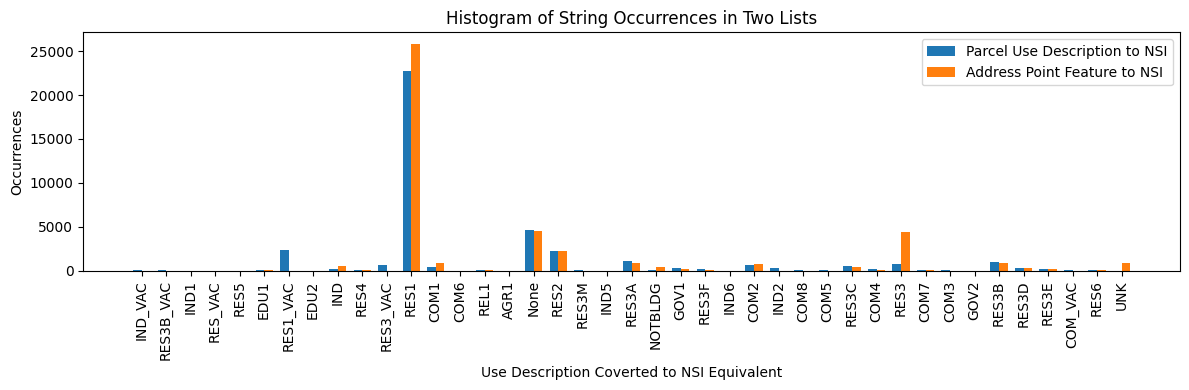

In [46]:
## EXPLORE: Plot comparison of results from parcel use descriptions and address point feature codes ##

# Create lists of NSI types that occur in tax data 
has_use_descritpion = ftpt_inv[ftpt_inv['UseDescription_NSI'].notna()]
use_descriptions = [item for sublist in has_use_descritpion['UseDescription_NSI'] for item in (sublist if isinstance(sublist, list) else [sublist])]
has_use_descritpion2 = ftpt_inv[ftpt_inv['FC_NSI'].notna()]
use_descriptions2 = [item for sublist in has_use_descritpion2['FC_NSI'] for item in (sublist if isinstance(sublist, list) else [sublist])]

# Count occurrences in each list
counter1 = Counter(use_descriptions)
counter2 = Counter(use_descriptions2)

# Combine keys from both lists
all_labels = list(set(counter1.keys()).union(set(counter2.keys())))

# Extract counts in the same order for both lists
counts1 = [counter1[label] for label in all_labels]
counts2 = [counter2[label] for label in all_labels]

# Define bar width
bar_width = 0.35
index = np.arange(len(all_labels))

# Create the plot
fig, ax = plt.subplots(figsize = (12,4))

# Plotting both lists' counts
bar1 = ax.bar(index, counts1, bar_width, label='Parcel Use Description to NSI', color='tab:blue')
bar2 = ax.bar(index + bar_width, counts2, bar_width, label='Address Point Feature to NSI', color='tab:orange')

# Add labels and title
ax.set_xlabel('Use Description Coverted to NSI Equivalent')
ax.set_ylabel('Occurrences')
ax.set_title('Histogram of String Occurrences in Two Lists')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(all_labels)
ax.legend()

# Show the plot
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## **SECTION 7: Clean Inventory Data and Prepare for Future Use**

In [47]:
# Load Inventory to Clean 
inventory = inv_local.json_to_gdf(dir_attribution + '/Local_Inventory_Point.json',crs_main)

# Convert numeric, single-entry columns to appropriate type 
float_columns = ['Scrape_Total_Value', 'Scrape_Improvement_Value']
int_columns = ['FootprintID', 'Num_Points', 'Local_Flag', 'Footprint_Flag']   

# Convert columns to appropriate type 
for col in float_columns:
    inventory[col] = inventory[col].astype(float)
for col in int_columns:
    inventory[col] = inventory[col].fillna(0)
    inventory[col] = inventory[col].astype(int)

# Rename columns 
inventory = inventory.rename(columns={
                                'Address_ID': 'Address_ID',
                                'FeatureCode': 'Address_FeatureCode', 
                                'Scrape_Use_Description': 'Tax_UseDescription',
                                'Scrape_Use_Code': 'Tax_UseCode',
                                'Scrape_Landslide': 'Tax_Landslide',
                                'Scrape_Liquefaction': 'Tax_Liquefaction',
                                'Scrape_Fault_Zone': 'Tax_FaultZone',
                                'Scrape_Total_Value': 'Tax_TotalValue',
                                'Scrape_Improvement_Value': 'Tax_ImprovementValue',
                                'Scrape_Homeowner_Exemption': 'Tax_HomeownerExemption',
                                'Scrape_Year_Built': 'Tax_YearBuilt',
                                'Scrape_Eff_Year_Built': 'Tax_EffYearBuilt',
                                'Scrape_Bldg_Class': 'Tax_BldgClass',
                                'Scrape_Construction': 'Tax_Construction',
                                'Scrape_Bldg_Area': 'Tax_BldgArea',
                                'Scrape_Num_Units': 'Tax_NumUnits',
                                'Scrape_Num_Stories': 'Tax_NumStories',
                                'Scrape_Parking': 'Tax_Parking',
                                'Num_Points': 'Address_NumPoints',
                                'FC_NSI': 'Address_FeatureCode_NSI',
                                'UseDescription_NSI': 'Tax_UseDescription_NSI'})

# Export
inv_local.gdf_to_json(inventory, dir_attribution + 'Local_Inventory_Final.json')

JSON File Saved
